# ACT 模型推理

加载训练好的 ACT 模型，输入图片和状态向量，输出预测的动作。

## 1. 导入依赖

In [482]:
import json, sys
from pathlib import Path

import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from act.configuration_act import ACTConfig
from act.modeling_act import ACTModel, ACTTemporalEnsembler

print(f"PyTorch {torch.__version__}")

PyTorch 2.10.0


## 2. 配置参数

In [483]:
# 测试 frame_000000.jpg 需要向左转  frame_000227.jpg 需要向右转
IMAGE_PATH = "output/dataset/videos/observation.images.fpv/chunk-000/frame_000227.jpg"
MODEL_PATH = "output/train/model.pt"
STATS_DIR  = "output/dataset"
STATE = None  # None = 自动全零，或手动指定: STATE = [0.1, 0.05]

print(f"图片: {IMAGE_PATH}")
print(f"模型: {MODEL_PATH}")
print(f"状态: {STATE}")

图片: output/dataset/videos/observation.images.fpv/chunk-000/frame_000227.jpg
模型: output/train/model.pt
状态: None


## 3. 工具函数

In [484]:
IMAGE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_device():
    if torch.cuda.is_available(): return "cuda"
    if torch.backends.mps.is_available(): return "mps"
    return "cpu"

def load_checkpoint(path, device):
    ckpt = torch.load(str(path), map_location=device, weights_only=False)
    if "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
        config_dict = ckpt.get("config", {})
        inf_mu = ckpt.get("inference_latent_mu")
        inf_log_sigma = ckpt.get("inference_latent_log_sigma")
    else:
        state_dict, config_dict = ckpt, {}
        inf_mu = inf_log_sigma = None

    config = ACTConfig(**config_dict)
    model = ACTModel(config)
    model.load_state_dict(state_dict)
    if inf_mu is not None:
        model.set_inference_latent(inf_mu, inf_log_sigma)
    model = model.to(device).eval()
    return model, config_dict

def load_stats(stats_dir):
    stats_path = Path(stats_dir) / "meta" / "stats.json"
    if not stats_path.exists():
        print(f"⚠ stats.json 不存在，使用默认参数")
        return {"state_q01": [0.,0.], "state_q99": [1.,1.], "action_q01": [0.,0.,0.], "action_q99": [1.,1.,1.]}
    with open(stats_path) as f:
        raw = json.load(f)
    return {
        "state_q01": raw["observation.state"]["q01"],
        "state_q99": raw["observation.state"]["q99"],
        "action_q01": raw["action"]["q01"],
        "action_q99": raw["action"]["q99"],
    }

def process_image(path, device):
    img = Image.open(path).convert("RGB")
    t = IMAGE_TRANSFORM(img)
    return t.unsqueeze(0).unsqueeze(0).to(device)  # [1,1,3,224,224]

def normalize_state(state, stats, device):
    q01 = torch.tensor(stats["state_q01"], dtype=torch.float32, device=device)
    q99 = torch.tensor(stats["state_q99"], dtype=torch.float32, device=device)
    s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    d = q99 - q01
    d = torch.where(d == 0, torch.tensor(1e-8, device=device), d)
    return 2 * (s - q01) / d - 1

def denormalize_action(action, stats, device):
    q01 = torch.tensor(stats["action_q01"], dtype=torch.float32, device=device)
    q99 = torch.tensor(stats["action_q99"], dtype=torch.float32, device=device)
    d = q99 - q01
    d = torch.where(d == 0, torch.tensor(1e-8, device=device), d)
    return (action + 1) / 2 * d + q01

print("工具函数就绪")

工具函数就绪


## 4. 加载模型 + 预处理

In [485]:
DEVICE = get_device()
print(f"设备: {DEVICE}")

# 加载模型
model, config_dict = load_checkpoint(MODEL_PATH, DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"参数: {n_params:,}  |  state_dim={config_dict.get('state_dim')}  action_dim={config_dict.get('action_dim')}")

# 加载归一化参数
stats = load_stats(STATS_DIR)

# 状态
if STATE is None:
    state = [0.0] * config_dict.get("state_dim", 2)
else:
    state = STATE
state_tensor = normalize_state(state, stats, DEVICE)
print(f"状态: {state} -> 归一化: {state_tensor.cpu().tolist()}")

# 预处理图片
image_tensor = process_image(IMAGE_PATH, DEVICE)
print(f"图片 tensor: {image_tensor.shape}")

# 显示输入图片
raw_img = Image.open(IMAGE_PATH).convert("RGB")
plt.figure(figsize=(3, 2.5), dpi=100)
plt.imshow(raw_img)
plt.title(Path(IMAGE_PATH).name, fontsize=9)
plt.axis("off")
plt.show()

设备: mps


FileNotFoundError: [Errno 2] No such file or directory: 'output/train/model.pt'

## 5. 推理

In [480]:
model.eval()
with torch.no_grad():
    output = model.forward(image_tensor, state_tensor, action_target=None, infer_cvae=True)
    action_chunk = output["action"]  # [1, chunk_size, action_dim]

action_chunk_denorm = denormalize_action(action_chunk[0], stats, DEVICE)
result_first_step = action_chunk_denorm[0].cpu().tolist()

dim_labels = ["left_vel", "right_vel", "gripper_target"][:action_chunk.shape[2]]
print(f"第一步: " + " | ".join(f"{l}={v:+.4f}" for l, v in zip(dim_labels, result_first_step)))

第一步: left_vel=+0.0051 | right_vel=+0.0003 | gripper_target=-0.0000


## 6. 结果

上一步执行完会打印第一步动作。

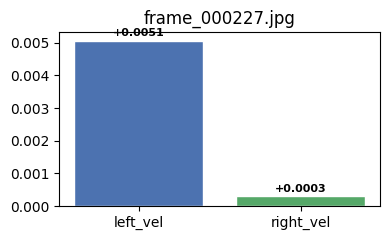

In [481]:
chunk_np = action_chunk_denorm.cpu().numpy()

# 柱状图
vel_labels = dim_labels[:2]
vel_values = result_first_step[:2]

fig, ax = plt.subplots(figsize=(4, 2.5), dpi=100)
bars = ax.bar(vel_labels, vel_values, color=["#4C72B0", "#55A868"], edgecolor="white")
ax.axhline(y=0, color="gray", linewidth=0.5)
ax.set_title(f"{Path(IMAGE_PATH).name}")
ax.bar_label(bars, fmt="%+.4f", fontsize=8, fontweight="bold", padding=2)
fig.tight_layout()
plt.show()